# Racing Vision — Car Detection & Tracking (v1)

Detect and track race cars in video footage using YOLOv8 + ByteTrack. This notebook is the foundation for the larger Racing Vision project (lap timing, speed estimation, overtakes, racing line) — v1 scope is **detection + tracking only**.

**Inputs:**
- Roboflow dataset (`data/roboflow_dataset/`) — 292 aerial/top-down images, single class `car`, YOLOv8 format.
- Two YouTube racing clips (`data/racing_clip1.mp4`, `data/racing_clip2.mp4`), likely ground-level/trackside angle.

**Key risk:** camera angle mismatch between the aerial training set and the ground-level clips — validated in the Angle Mismatch section below before any fine-tuning is attempted.

**Pipeline:** frame extraction (OpenCV) → detection (YOLOv8) → tracking (ByteTrack via `supervision`) → annotated video + CSV log.

## Setup

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO

DATA_DIR = Path("data")
ROBOFLOW_DIR = DATA_DIR / "roboflow_dataset"
OUTPUTS_DIR = Path("outputs")
RUNS_DIR = Path("runs")
CLIP_PATHS = [DATA_DIR / "racing_clip1.mp4", DATA_DIR / "racing_clip2.mp4"]

OUTPUTS_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


objc[16115]: Class AVFFrameReceiver is implemented in both /opt/homebrew/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10d9943a8) and /opt/homebrew/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11a0cc3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[16115]: Class AVFAudioReceiver is implemented in both /opt/homebrew/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10d9943f8) and /opt/homebrew/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11a0cc3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/arjunsk9876/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
def sample_frames(video_path, n=6):
    """Evenly sample n frames (as BGR numpy arrays) from a video file."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = [int(i * total / n) for i in range(n)]
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok:
            frames.append(frame)
    cap.release()
    return frames


def show_frames(frames, titles=None, cols=3, figsize_per=(4, 3)):
    """Display a list of BGR frames inline in a grid."""
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per[0] * cols, figsize_per[1] * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i, ax in enumerate(axes):
        if i < len(frames):
            ax.imshow(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB))
            if titles:
                ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Track A: Pretrained YOLOv8 Baseline

In [3]:
model_pretrained = YOLO("yolov8n.pt")
model_pretrained.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

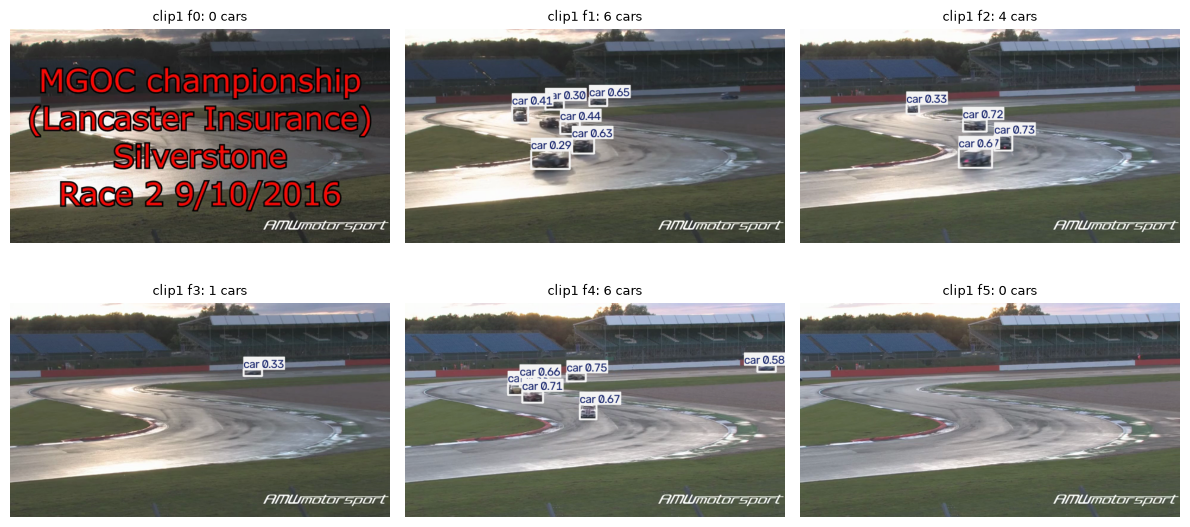

In [4]:
# COCO classes that correspond to cars/vehicles
VEHICLE_CLASS_IDS = [2, 5, 7]  # car, bus, truck

clip1_frames = sample_frames(CLIP_PATHS[0], n=6)
clip1_results = [model_pretrained(f, classes=VEHICLE_CLASS_IDS, verbose=False)[0] for f in clip1_frames]
clip1_annotated = [r.plot() for r in clip1_results]
clip1_counts = [len(r.boxes) for r in clip1_results]

for i, frame in enumerate(clip1_annotated):
    cv2.imwrite(str(OUTPUTS_DIR / f"trackA_pretrained_clip1_frame{i}.jpg"), frame)

show_frames(clip1_annotated, titles=[f"clip1 f{i}: {c} cars" for i, c in enumerate(clip1_counts)])

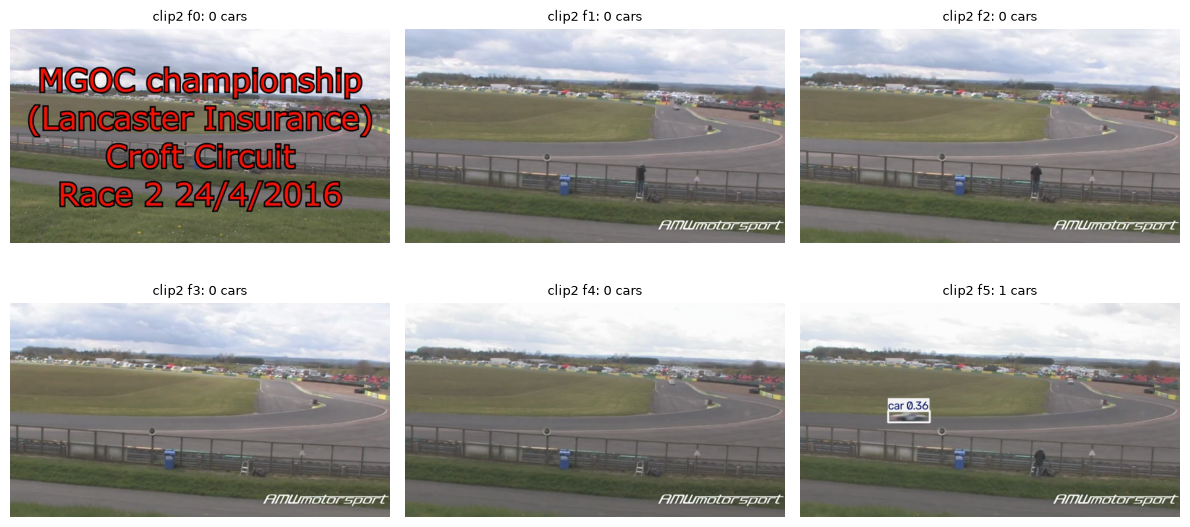

In [5]:
clip2_frames = sample_frames(CLIP_PATHS[1], n=6)
clip2_results = [model_pretrained(f, classes=VEHICLE_CLASS_IDS, verbose=False)[0] for f in clip2_frames]
clip2_annotated = [r.plot() for r in clip2_results]
clip2_counts = [len(r.boxes) for r in clip2_results]

for i, frame in enumerate(clip2_annotated):
    cv2.imwrite(str(OUTPUTS_DIR / f"trackA_pretrained_clip2_frame{i}.jpg"), frame)

show_frames(clip2_annotated, titles=[f"clip2 f{i}: {c} cars" for i, c in enumerate(clip2_counts)])

In [6]:
print("clip1 per-frame vehicle counts:", clip1_counts)
print("clip2 per-frame vehicle counts:", clip2_counts)
print(f"clip1 mean: {sum(clip1_counts)/len(clip1_counts):.2f}, clip2 mean: {sum(clip2_counts)/len(clip2_counts):.2f}")

clip1 per-frame vehicle counts: [0, 6, 4, 1, 6, 0]
clip2 per-frame vehicle counts: [0, 0, 0, 0, 0, 1]
clip1 mean: 2.83, clip2 mean: 0.17


**Track A summary:** pretrained `yolov8n.pt` (COCO car/bus/truck classes) run on 6 sampled frames from each clip.

- clip1 per-frame counts: `[0, 6, 4, 1, 6, 0]` — mean **2.83**
- clip2 per-frame counts: `[0, 0, 0, 0, 0, 1]` — mean **0.17**

clip2 detection rate is far below the ≥80%-of-visible-cars target — pretrained COCO weights are struggling on that clip. Worth checking camera angle/scale/resolution differences before concluding fine-tuning (Track B) is the fix, since Track B trains on aerial data and may not transfer to a ground-level clip either. Annotated frames saved to `outputs/trackA_pretrained_*`.

## Angle Mismatch Validation

## Track B: Fine-tuned YOLOv8 on Roboflow Dataset

## Comparison: Pretrained vs. Fine-tuned

## Tracking Demo: ByteTrack

## Conclusion